In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn import tree
from sklearn import metrics


# Load data

In [ ]:
data = pd.read_csv('data/flowmeter_A.txt', sep="\t", header=None).dropna()

data.head()

#data = data.iloc[:, 0:5]

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,0.841499,1.009367,0.993816,8.469805,10.278727,10.037759,8.501365,8.581726,10.247763,10.058822,...,32.451173,34.568685,33.082683,36.722005,36.969403,36.075847,36.051432,35.174155,32.729490,1
1,0.842250,1.006584,0.996605,7.531891,9.139924,8.951618,7.612213,7.623325,9.106345,8.945142,...,32.428385,34.441732,33.081055,36.687825,36.933595,36.054688,35.979818,34.847005,32.731122,1
2,0.840723,1.011647,0.998152,6.641699,7.975464,7.857692,6.593117,6.681572,7.964596,7.814698,...,32.428385,34.275715,33.113605,36.661785,36.873370,36.002605,35.963542,34.689128,32.771810,1
3,0.841119,1.017807,0.996812,5.687524,6.824334,6.689885,5.615428,5.763315,6.801051,6.686639,...,32.485350,34.080403,33.170573,36.673177,36.811525,35.974935,35.955403,34.500328,32.849935,1
4,0.840358,1.016534,0.996221,5.660385,6.829560,6.675628,5.623977,5.736818,6.813453,6.672377,...,32.503255,34.122720,33.164062,36.673177,36.826173,35.996095,35.968425,34.474283,32.853190,1


In [4]:
from scipy import stats
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib

def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax):
    
    # This is the space between the end of the bar and the label
    padding = 0.05
    
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle

        value_ = value

        if value < 0:
            value_ = 0
        
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        # And finally add the text
        ax.text(
            x=angle, 
            y=value_ + padding, 
            s=str(label) + '; ' + "{:.2f}".format(value), 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor"
        ) 

def plot_matrix(data, selection = 'all'):


    fig, axs0 = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})


    # get redundant pairs
    pairs_to_drop = set()
    cols = data.columns
    for i in range(0, data.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    
    # get top abs correlations
    au_corr = data.corr().unstack()
    labels_to_drop = pairs_to_drop
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)


    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    colors = [plt.cm.RdYlGn(norm(c)) for c in au_corr.values]

    ANGLES = np.linspace(0, 2 * np.pi, len(au_corr), endpoint=False)
    VALUES = au_corr
    LABELS = au_corr.index.tolist()
    

    WIDTH = 1.0 * np.pi / len(VALUES)
    OFFSET = np.pi / 2

    axs0.set_theta_offset(OFFSET)

    axs0.set_ylim(-1, 1)

    axs0.set_frame_on(False)

    # au_corr.plot.bar(ax = axs0, color=colors)
    axs0.bar(
    ANGLES, VALUES, width=WIDTH, linewidth=2,
    color=colors)


    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='large')


    axs0.xaxis.grid(False)
    axs0.yaxis.grid(False)
    axs0.set_xticks([])
    axs0.set_yticks([])
    
    #add_labels(ANGLES, VALUES, LABELS, OFFSET, axs0)

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.RdYlGn), ax=axs0, shrink = 0.7, aspect = 30, orientation = 'horizontal', pad = 0)
    
    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Pearson\ coefficient$', fontsize = 'x-large')

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=16
    plt.rcParams['axes.linewidth'] = 1 

    plt.tight_layout()
    plt.savefig(f'figures/example-6-2-matrix_bar_{selection}.png', dpi = 300)
    plt.show()

    return au_corr

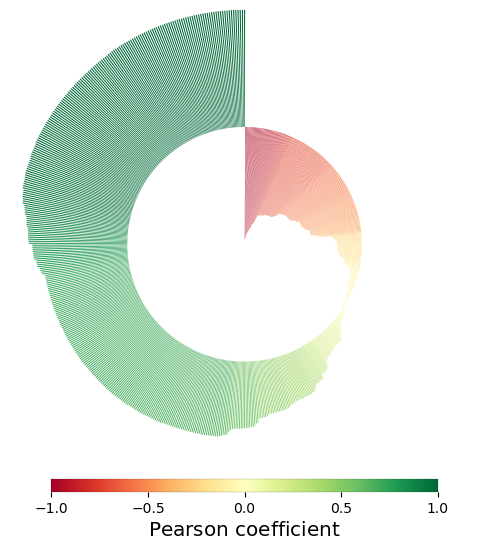

In [5]:
au_corr = plot_matrix(data)

In [6]:
feats_to_drop = []

for feat_pair in au_corr.index.tolist():

    if abs(au_corr[feat_pair] > 0.9):
        feats_to_drop.append(int(feat_pair[-1]))

feats_to_drop = [i for i in set(feats_to_drop)]

print(feats_to_drop) 

data2 = data.drop(labels=feats_to_drop, axis=1)

data2.columns

[4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 25, 26, 28, 29, 31, 32, 33, 34, 35]


Index([0, 1, 2, 3, 11, 21, 22, 24, 27, 30, 36], dtype='int64')

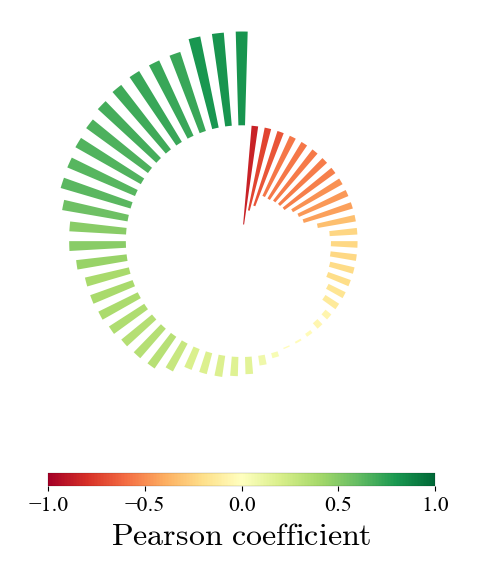

In [7]:
au_corr2 = plot_matrix(data2, selection = 'corr9')

# Preprocess data

In [8]:
data = data2

data = data.to_numpy()

x = data[:, :-1]
y = data[:, -1]

#We want classes to be 0 and 1
for i in range(len(y)):
    if y[i] == 1:
        y[i] = 0

    else:
        y[i] = 1

#Data preprocessing
scaler = StandardScaler()
x = scaler.fit_transform(x)

#Create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.5,
                                                    shuffle=True,
                                                    random_state=74)

# Train a decision tree model

In [9]:
#Create DT model
DT_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)

#Train the model
DT_classifier.fit(X_train, y_train)

#Test the model
DT_predicted = DT_classifier.predict(X_test)

DT_accuracy = metrics.accuracy_score(y_test, DT_predicted)

print(DT_accuracy)


0.9090909090909091



# Train a support vector machine model

In [10]:
#Create SVC model
SVC_classifier = SVC(random_state = 42)

#Train the model
SVC_classifier.fit(X_train, y_train)

#Test the model
SVC_predicted = SVC_classifier.predict(X_test)

SVC_accuracy = metrics.accuracy_score(y_test, SVC_predicted)

print(SVC_accuracy)

0.7272727272727273


# Train an artificial neural network (MLP) model

In [11]:
#Create MLP model
MLP_classifier = MLPClassifier(random_state = 42, max_iter=3000)

#Train the model
MLP_classifier.fit(X_train, y_train)

#Test the model
MLP_predicted = MLP_classifier.predict(X_test)

MLP_accuracy = metrics.accuracy_score(y_test, MLP_predicted)

print(MLP_accuracy)




0.8409090909090909


# Compare results with default hyperparameters

In [12]:
def plot_roc(clfs, test = 'default'):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for clf in clfs:
        metrics.RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axs0, linewidth = 1)

    axs0.xaxis.label.set_size('medium')
    axs0.yaxis.label.set_size('medium')

    axs0.tick_params(direction='out',
                            pad=10,
                            length=9,
                            width=1,
                            labelsize='medium')

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='medium')

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 
    plt.legend(frameon = False)
    plt.tight_layout()
    plt.savefig(f'figures/example-6-1-{test}.png', dpi = 300)
    plt.show()

    return None

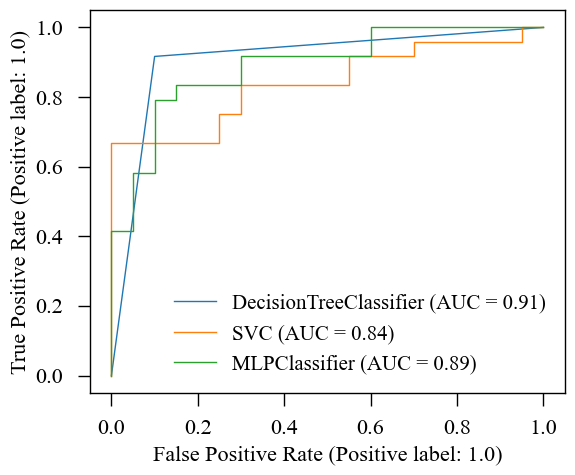

In [13]:
clfs = [
        DT_classifier,
        SVC_classifier,
        MLP_classifier
    ]
    
plot_roc(clfs)

## Get model structures

In [14]:
for i, layer in enumerate(MLP_classifier.coefs_):
    print(f'layer_{i}: {len(MLP_classifier.coefs_[i])})')

layer_0: 10)
layer_1: 100)


[Text(0.4, 0.9, 'x[0] <= -0.142\nentropy = 0.933\nsamples = 43\nvalue = [15, 28]'),
 Text(0.2, 0.7, 'entropy = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.6, 0.7, 'x[2] <= 1.149\nentropy = 0.932\nsamples = 23\nvalue = [15, 8]'),
 Text(0.4, 0.5, 'x[0] <= 0.919\nentropy = 0.742\nsamples = 19\nvalue = [15, 4]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.6, 0.3, 'x[2] <= -0.753\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]'),
 Text(0.4, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.1, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]')]

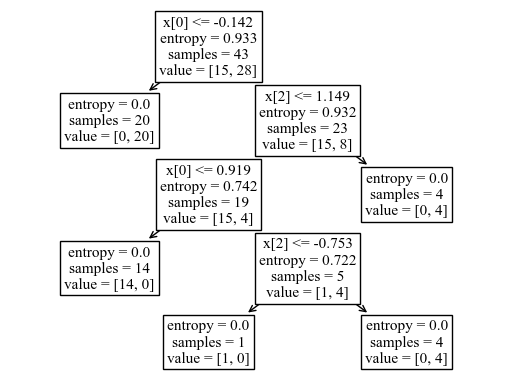

In [15]:
tree.plot_tree(DT_classifier)

# Performance with improved hyperparameters

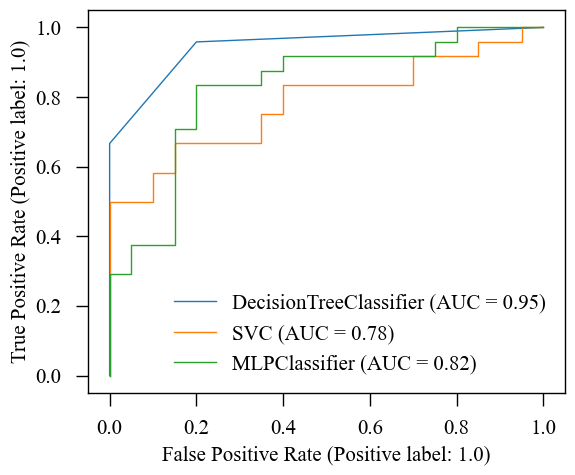

In [16]:
DT_classifier_improved = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, random_state = 42)
SVC_classifier_improved = SVC(C = 0.1, random_state = 42)
MLP_classifier_improved = MLPClassifier(hidden_layer_sizes = (10, ), random_state = 42, max_iter=3000)

clfs_improved = [
    DT_classifier_improved, 
    SVC_classifier_improved,
    MLP_classifier_improved
]



for clf in clfs_improved:
    #Train the model
    clf.fit(X_train, y_train)

plot_roc(clfs_improved, test = 'improved')

## Get model structures

In [17]:
for i, layer in enumerate(MLP_classifier_improved.coefs_):
    print(f'layer_{i}: {len(MLP_classifier_improved.coefs_[i])})')

layer_0: 10)
layer_1: 10)


[Text(0.4, 0.875, 'x[0] <= -0.142\nentropy = 0.933\nsamples = 43\nvalue = [15, 28]'),
 Text(0.2, 0.625, 'entropy = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.6, 0.625, 'x[2] <= 1.149\nentropy = 0.932\nsamples = 23\nvalue = [15, 8]'),
 Text(0.4, 0.375, 'x[0] <= 0.919\nentropy = 0.742\nsamples = 19\nvalue = [15, 4]'),
 Text(0.2, 0.125, 'entropy = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.6, 0.125, 'entropy = 0.722\nsamples = 5\nvalue = [1, 4]'),
 Text(0.8, 0.375, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]')]

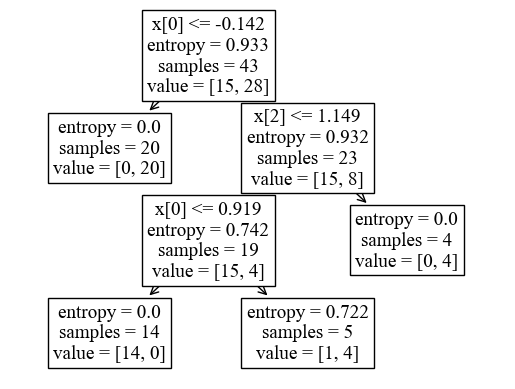

In [18]:
tree.plot_tree(DT_classifier_improved)